In [1]:
import open3d as o3d
import os
import glob
import numpy as np
import h5py
from matplotlib import pyplot as plt
from generate_hdf5_dataset_with_padding import generate_hdf5_dataset_with_padding
from segmentation_dataset_prep import generate_object_segmentation_dataset
import random
import getpass
import h5py
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
0.17.0
numpy version:  1.21.6


# 1 Element Dataset Generation

In [25]:
# CHANGEABLES
NUM_SAMPLES = 1200
NUM_POINTS = 4096
my_product_name = "ketchup_heinz_400ml"

MINIMARKET_ROOT = r"D:\Datasets\MinimarketPointCloud"
RAW_DATASET_DIR = os.path.join(MINIMARKET_ROOT,"MiniMarket_raw")
POINTCLOUD_SAVE_DIR = os.path.join(MINIMARKET_ROOT,"MiniMarket_point_clouds",str(NUM_POINTS))


# RESULTS DIRS
MY_PRODUCT_READ_DIR = os.path.join(RAW_DATASET_DIR, my_product_name)
my_product_pcdataset_name = my_product_name+ "_" + str(NUM_SAMPLES) + "_" + str(NUM_POINTS)
my_product_pcdataset_hdf5_file = my_product_pcdataset_name + ".h5"
MY_PRODUCT_PCDATASET_SAVE_DIR = os.path.join(POINTCLOUD_SAVE_DIR, my_product_pcdataset_hdf5_file)
# if not os.path.exists(MY_PRODUCT_PCDATASET_SAVE_DIR):
#     os.makedirs(MY_PRODUCT_PCDATASET_SAVE_DIR)
print("MY_PRODUCT_PCDATASET_SAVE_DIR: ", MY_PRODUCT_PCDATASET_SAVE_DIR)

MY_PRODUCT_PCDATASET_SAVE_DIR:  D:\Datasets\MinimarketPointCloud\MiniMarket_point_clouds\4096\ketchup_heinz_400ml_1200_4096.h5


In [26]:
generate_hdf5_dataset_with_padding(MY_PRODUCT_READ_DIR, MY_PRODUCT_PCDATASET_SAVE_DIR, NUM_POINTS);

path_:  D:\Datasets\MinimarketPointCloud\MiniMarket_raw\ketchup_heinz_400ml
files ['D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam1.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam2.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam3.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam4.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam5.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam6.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam7.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\ketchup_heinz_400ml\\angle_10_light_1_noise_1_cam8.pcd', 'D:\\Datasets\\MinimarketPointCloud\\

In [19]:
# Open the file in read mode
with h5py.File(MY_PRODUCT_PCDATASET_SAVE_DIR, 'r') as f:
    # Read datasets
    point_clouds = f["point_clouds"][:]  # shape: (1200, 2048, 3)
    color_clouds = f["color_clouds"][:]  # shape: (1200, 2048, 3)
print(point_clouds.shape)
print(color_clouds.shape)

(1200, 4096, 3)
(1200, 4096, 3)


Random sample index: 1179


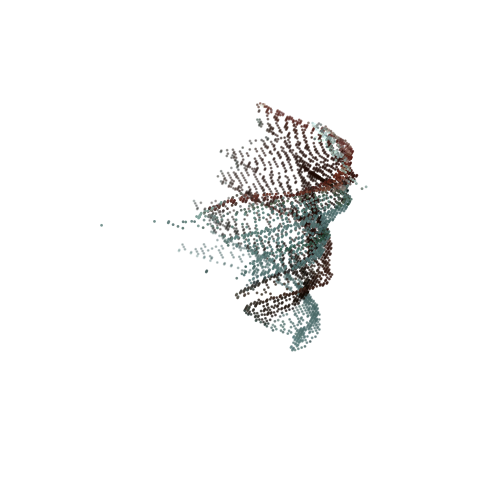

In [20]:
N = random.randint(0, NUM_SAMPLES-1)
print("Random sample index:", N)
points_sample = point_clouds[N, :, :]
colors_sample = color_clouds[N, :, :]

fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(points_sample[:, 0], points_sample[:, 1], points_sample[:, 2],
           c=colors_sample, s=1)
ax.set_axis_off()
plt.show()


In [8]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points_sample)
pcd.colors = o3d.utility.Vector3dVector(colors_sample)
o3d.visualization.draw_geometries([pcd])

# ALL ELEMENTS DATASET GENERATION

In [2]:
# CHANGEABLES
NUM_SAMPLES = 1200
NUM_POINTS = 4096

MINIMARKET_ROOT = r"D:\Datasets\MinimarketPointCloud"
RAW_DATASET_DIR = os.path.join(MINIMARKET_ROOT,"MiniMarket_raw")
POINTCLOUD_SAVE_DIR = os.path.join(MINIMARKET_ROOT,"MiniMarket_point_clouds",str(NUM_POINTS))

for my_product_name in os.listdir(RAW_DATASET_DIR):
    print("my_product_name: ", my_product_name)
    # RESULTS DIRS
    MY_PRODUCT_READ_DIR = os.path.join(RAW_DATASET_DIR, my_product_name)
    my_product_pcdataset_name = my_product_name+ "_" + str(NUM_SAMPLES) + "_" + str(NUM_POINTS)
    my_product_pcdataset_hdf5_file = my_product_pcdataset_name + ".h5"
    MY_PRODUCT_PCDATASET_SAVE_DIR = os.path.join(POINTCLOUD_SAVE_DIR, my_product_pcdataset_hdf5_file)
    # if not os.path.exists(MY_PRODUCT_PCDATASET_SAVE_DIR):
    #     os.makedirs(MY_PRODUCT_PCDATASET_SAVE_DIR)
    generate_hdf5_dataset_with_padding(MY_PRODUCT_READ_DIR, MY_PRODUCT_PCDATASET_SAVE_DIR, NUM_POINTS);

my_product_name:  biscuits_belvita_breakfast_biscuits_golden_oats_5_pack_225gm
path_:  D:\Datasets\MinimarketPointCloud\MiniMarket_raw\biscuits_belvita_breakfast_biscuits_golden_oats_5_pack_225gm
files ['D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\biscuits_belvita_breakfast_biscuits_golden_oats_5_pack_225gm\\angle_10_light_1_noise_1_cam1.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\biscuits_belvita_breakfast_biscuits_golden_oats_5_pack_225gm\\angle_10_light_1_noise_1_cam2.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\biscuits_belvita_breakfast_biscuits_golden_oats_5_pack_225gm\\angle_10_light_1_noise_1_cam3.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\biscuits_belvita_breakfast_biscuits_golden_oats_5_pack_225gm\\angle_10_light_1_noise_1_cam4.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_raw\\biscuits_belvita_breakfast_biscuits_golden_oats_5_pack_225gm\\angle_10_light_1_noise_1_cam5.pcd', 'D:\\Datasets\\MinimarketPointCloud\\MiniM

KeyboardInterrupt: 

# Segmentation Dataset Generation

In [2]:
# CHANGEABLES
NUM_SAMPLES = 1200
NUM_POINTS = 4096
my_product_name = "ketchup_heinz_400ml"

MINIMARKET_ROOT = r"D:\Datasets\MinimarketPointCloud"
POINTCLOUD_SAVE_DIR = os.path.join(MINIMARKET_ROOT,"MiniMarket_point_clouds",str(NUM_POINTS))

# RESULTS DIRS
my_product_pcdataset_name = my_product_name+ "_" + str(NUM_SAMPLES) + "_" + str(NUM_POINTS)
my_product_pcdataset_hdf5_file = my_product_pcdataset_name + ".h5"
SEGMENTATION_SAVE_DIR = os.path.join(POINTCLOUD_SAVE_DIR,"segmentation_dataset",my_product_name)

TARGET_OBJECT_NAME = my_product_pcdataset_hdf5_file

In [3]:
generate_object_segmentation_dataset( POINTCLOUD_SAVE_DIR, TARGET_OBJECT_NAME, SEGMENTATION_SAVE_DIR, 10 )

(1200, 4096, 3)
(1200, 4096, 3)
iteration:  1 , processing sample: 0 , number of alien objects = 0
copy_alien_files:  []
NUM_POINTS_PER_SEG_SAMPLE:  40960
seg_sample_point.shape:  (4096, 3)
seg_sample_color.shape:  (4096, 3)
iteration:  1 , processing sample: 1 , number of alien objects = 3
copy_alien_files:  ['D:\\Datasets\\MinimarketPointCloud\\MiniMarket_point_clouds\\4096\\hair_and_body_wash_childs_farm_organic_sweet_orange_250ml_1200_4096.h5', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_point_clouds\\4096\\hazelnut_cocoa_spread_nutella_350gm_1200_4096.h5', 'D:\\Datasets\\MinimarketPointCloud\\MiniMarket_point_clouds\\4096\\liquid_handwash_palmolive_milk_and_honey_300ml_1200_4096.h5']
NUM_POINTS_PER_SEG_SAMPLE:  40960
seg_sample_point.shape:  (16384, 3)
seg_sample_color.shape:  (16384, 3)
iteration:  1 , processing sample: 2 , number of alien objects = 6
copy_alien_files:  ['D:\\Datasets\\MinimarketPointCloud\\MiniMarket_point_clouds\\4096\\coffee_instant_kenco_millicano_americ

(1200, 40960, 3)
(1200, 40960, 3)
(1200, 40960, 2)
Random sample index: 757


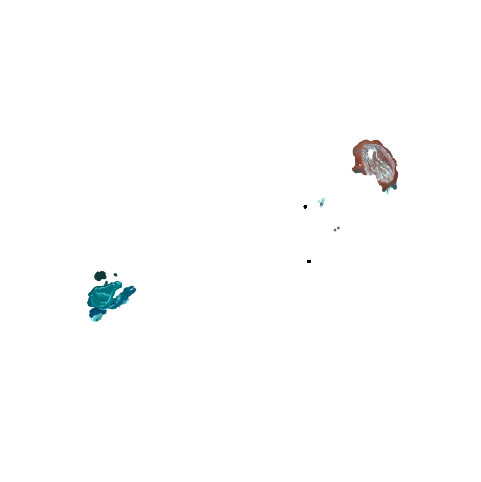

In [ ]:
PC_SEGMMENTATION_DIR = r"D:\Datasets\MinimarketPointCloud\MiniMarket_point_clouds\4096\segmentation_dataset\ketchup_heinz_400mlketchup_heinz_400ml_1200_4096_segmentation_40960_1200.h5"
                        
# Open the file in read mode
with h5py.File(PC_SEGMMENTATION_DIR, 'r') as f:
    # Read datasets
    seg_points = f["seg_points"][:]  # shape: (1200, 2048, 3)
    seg_colors = f["seg_colors"][:]  # shape: (1200, 2048, 3)
    seg_labels = f["seg_labels"][:]  # shape: (1200, 2048, 3)
print(seg_points.shape)
print(seg_colors.shape)
print(seg_labels.shape)


Random sample index: 508


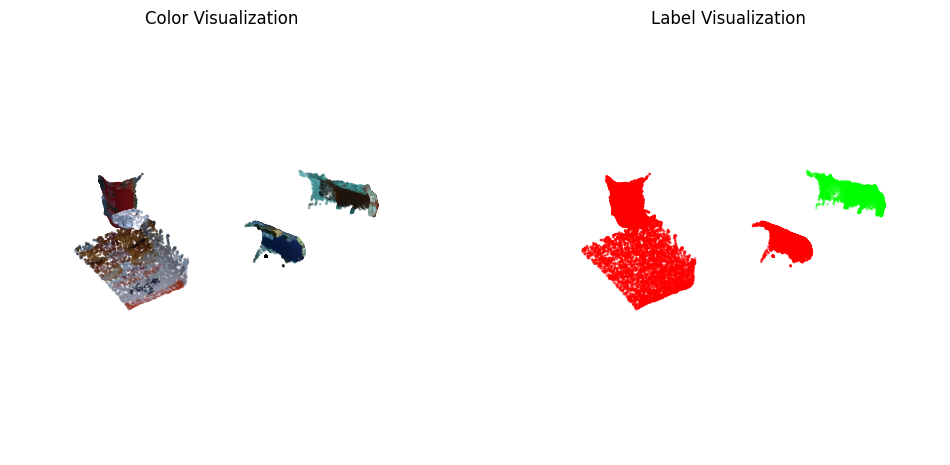

In [37]:
N = random.randint(0, seg_points.shape[0]-1)
print("Random sample index:", N)
points_sample = seg_points[N, :, :]
colors_sample = seg_colors[N, :, :]
labels_sample = np.where((seg_labels[N, :, :] == np.array([1, 0])).all(axis=1, keepdims=True), [0, 1, 0], [1, 0, 0])

fig = plt.figure(figsize=(12, 6))

# First subplot for color visualization
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(points_sample[:, 0], points_sample[:, 1], points_sample[:, 2],
            c=colors_sample, s=1)
ax1.set_title("Color Visualization")
ax1.set_axis_off()

# Second subplot for label visualization
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(points_sample[:, 0], points_sample[:, 1], points_sample[:, 2],
            c=labels_sample, s=1)
ax2.set_title("Label Visualization")
ax2.set_axis_off()

plt.show()



In [39]:
pcd_colors = o3d.geometry.PointCloud()
pcd_colors.points = o3d.utility.Vector3dVector(points_sample)
pcd_colors.colors = o3d.utility.Vector3dVector(colors_sample)
o3d.visualization.draw_geometries([pcd_colors], window_name="Color Visualization")

pcd_labels = o3d.geometry.PointCloud()
pcd_labels.points = o3d.utility.Vector3dVector(points_sample)
pcd_labels.colors = o3d.utility.Vector3dVector(labels_sample)
o3d.visualization.draw_geometries([pcd_labels], window_name="Label Visualization")

